# AICE Associate 대비 실습 과정 — 5회차
## AI 모델링 필수 개념, 지도학습 I (선형회귀 · 로지스틱 회귀)

> **과정 구성**: 총 8회 × 3시간, 실습 위주  
> **선수 학습**: 1~4회차. 오늘부터는 **실제 공개 데이터** 두 가지로 모델을 만듭니다.  
> - **캘리포니아 주택 가격** (`california_housing_train.csv`, 17,000행): 구역별 주택 가격 예측 → **회귀**  
> - **타이타닉 승객** (`titanic_train.csv`, 891행): 생존 여부 예측 → **분류**

### 전체 커리큘럼

| 회차 | 주제 | 핵심 키워드 |
|:---:|------|------------|
| 1 | AI/ML/DL 개요, 데이터 획득하기 | AI ⊃ ML ⊃ DL, 지도/비지도, `read_csv`, `read_excel`, `to_csv` |
| 2 | 데이터 구조 확인하기, 기초 데이터 다루기 | `info`, `describe`, `loc/iloc`, 필터링, 정렬, `groupby`, `merge` |
| 3 | 데이터 이해하기 (EDA) | 분포, 상관관계, `matplotlib`, `seaborn`, 가설 검증 |
| 4 | 데이터 전처리하기 | 결측치, 이상치, 구간화, 인코딩, 스케일링, `train_test_split` |
| **5** | **AI 모델링 필수 개념, 지도학습 I** | 과적합, 평가지표, 선형회귀, 로지스틱 회귀 |
| 6 | 지도학습 II | 의사결정나무, 앙상블, 랜덤포레스트, 그라디언트부스팅 |
| 7 | 인공신경망, 심층신경망, 딥러닝 프레임워크 | 퍼셉트론, 활성화함수, Keras `Sequential`, `EarlyStopping` |
| 8 | 비지도학습, 모델 성능 향상시키기 | K-Means, PCA, 교차검증, 하이퍼파라미터 튜닝, 모의고사 |

### 오늘의 학습 목표

1. 학습(`fit`)이 무엇을 하는지, 파라미터와 하이퍼파라미터의 차이를 설명할 수 있다.
2. 과적합·과소적합을 train/test 점수로 진단하고 대처 방향을 말할 수 있다.
3. scikit-learn 의 공통 문법 `fit` → `predict` → `score` 로 어떤 모델이든 다룰 수 있다.
4. **선형회귀** 를 학습시켜 계수를 해석하고 MAE / MSE / RMSE / R² 로 평가할 수 있다.
5. **로지스틱 회귀** 로 확률을 예측하고 혼동행렬, 정확도 / 정밀도 / 재현율 / F1, ROC-AUC 로 평가할 수 있다.
6. 상황에 따라 **어떤 평가지표를 봐야 하는지** 판단할 수 있다.

### 시간 계획 (180분)

| 시간 | 내용 |
|------|------|
| 00:00 ~ 00:10 | 0. 환경 준비, 데이터 불러오기 |
| 00:10 ~ 00:50 | 1. 모델링 필수 개념 |
| 00:50 ~ 01:00 | 휴식 |
| 01:00 ~ 01:55 | 2. 선형회귀 (캘리포니아 주택 가격) |
| 01:55 ~ 02:05 | 휴식 |
| 02:05 ~ 02:45 | 3. 로지스틱 회귀 (타이타닉 생존) |
| 02:45 ~ 03:00 | 4. 종합 실습, 정리 |

---
## 0. 환경 준비, 데이터 불러오기

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = "data"
print("pandas", pd.__version__)

pandas 2.2.1


In [2]:
# 한글 폰트 설정 (1회차와 동일). Colab 은 나눔폰트 설치 후 런타임 재시작 필요.
#   !apt-get -qq install fonts-nanum
#   !rm -rf ~/.cache/matplotlib
from matplotlib import font_manager


def set_korean_font() -> str:
  candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
  installed = {f.name for f in font_manager.fontManager.ttflist}
  for name in candidates:
    if name in installed:
      plt.rcParams["font.family"] = name
      plt.rcParams["axes.unicode_minus"] = False
      return name
  plt.rcParams["axes.unicode_minus"] = False
  return "(한글 폰트 없음 - 그래프의 한글이 깨질 수 있음)"


print("적용된 폰트:", set_korean_font())

sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0], rc={"axes.unicode_minus": False})

적용된 폰트: AppleGothic


In [3]:
# ===== 실습 데이터: 캘리포니아 주택 가격(회귀), 타이타닉 생존(분류) =====
# data/ 폴더에 아래 파일이 있어야 합니다. (Colab 이면 왼쪽 파일 탭에서 data/ 폴더를 만들고 업로드)
#   california_housing_train.csv, california_housing_test.csv, titanic_train.csv, titanic_test.csv
# 원본 컬럼명은 영어라서 읽은 뒤 한글로 바꿉니다. (영어 = 한글 대응표는 아래 사전 참고)

HOUSING_COLS = {
  "longitude": "경도",                 # 서쪽일수록 작은 값 (-124 ~ -114)
  "latitude": "위도",                  # 북쪽일수록 큰 값 (32 ~ 42)
  "housing_median_age": "주택연식",    # 그 구역 주택 나이의 중앙값 (년)
  "total_rooms": "총방수",             # 구역 내 전체 방 수
  "total_bedrooms": "총침실수",        # 구역 내 전체 침실 수
  "population": "인구",                # 구역 인구
  "households": "가구수",              # 구역 가구 수
  "median_income": "소득중앙값",       # 가구 소득 중앙값 (단위: 만 달러)
  "median_house_value": "주택가격",    # 구역 주택 가격의 중앙값 (달러) <- 회귀 타깃
}
TITANIC_COLS = {
  "PassengerId": "승객ID",
  "Survived": "생존",                  # 1 = 생존, 0 = 사망 <- 분류 타깃
  "Pclass": "객실등급",                # 1등석 / 2등석 / 3등석
  "Name": "이름",
  "Sex": "성별",                       # male / female
  "Age": "나이",
  "SibSp": "동반형제배우자",           # 함께 탄 형제·배우자 수
  "Parch": "동반부모자녀",             # 함께 탄 부모·자녀 수
  "Ticket": "티켓번호",
  "Fare": "운임",                      # 지불한 요금 (파운드)
  "Cabin": "객실번호",
  "Embarked": "탑승항구",              # C = Cherbourg, Q = Queenstown, S = Southampton
}

for name in ["california_housing_train.csv", "california_housing_test.csv", "titanic_train.csv", "titanic_test.csv"]:
  if not os.path.exists(f"{DATA_DIR}/{name}"):
    raise FileNotFoundError(f"{DATA_DIR}/{name} 가 없습니다. data 폴더에 실습 파일을 넣어 주세요.")

housing = pd.read_csv(f"{DATA_DIR}/california_housing_train.csv").rename(columns=HOUSING_COLS)
housing_test = pd.read_csv(f"{DATA_DIR}/california_housing_test.csv").rename(columns=HOUSING_COLS)
titanic = pd.read_csv(f"{DATA_DIR}/titanic_train.csv").rename(columns=TITANIC_COLS)
titanic_test = pd.read_csv(f"{DATA_DIR}/titanic_test.csv").rename(columns=TITANIC_COLS)

print("housing:", housing.shape, "| housing_test:", housing_test.shape)
print("titanic:", titanic.shape, "| titanic_test:", titanic_test.shape)

housing: (17000, 9) | housing_test: (3000, 9)
titanic: (891, 12) | titanic_test: (418, 11)


In [4]:
housing.head(3)

,경도,위도,주택연식,총방수,총침실수,인구,가구수,소득중앙값,주택가격
0,-114.31,34.19,15.00,"5,612.00","1,283.00","1,015.00",472.00,1.49,"66,900.00"
1,-114.47,34.40,19.00,"7,650.00","1,901.00","1,129.00",463.00,1.82,"80,100.00"
2,-114.56,33.69,17.00,720.00,174.00,333.00,117.00,1.65,"85,700.00"


In [5]:
titanic.head(3)

,승객ID,생존,객실등급,이름,성별,나이,동반형제배우자,동반부모자녀,티켓번호,운임,객실번호,탑승항구
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S


---
## 1. AI 모델링 필수 개념

### 1.1 "학습한다" 는 것의 정체

#### 한 줄 정의
**학습 (fit)**: 데이터에 가장 잘 맞는 **파라미터(숫자들)** 를 찾는 것.

#### 직관적 설명
1회차에서 `LinearRegression` 이 섭씨→화씨 규칙 `y = 1.8x + 32` 를 찾았습니다. 여기서 **1.8 과 32 가 파라미터** 입니다. 모델은 "y = w·x + b" 라는 **틀** 만 알고 있고, 학습은 오차가 가장 작아지는 **w, b 값을 찾는 과정** 입니다.

| 용어 | 누가 정하나 | 예시 |
|------|------|------|
| **파라미터** (parameter) | **모델이 학습으로** | 회귀 계수 `coef_`, 절편 `intercept_`, 신경망 가중치 |
| **하이퍼파라미터** (hyperparameter) | **사람이 학습 전에** | 트리 깊이 `max_depth`, 규제 강도 `C`, 학습률, `n_estimators` |

> 하이퍼파라미터를 잘 고르는 방법(GridSearch)은 8회차에서 다룹니다. 오늘은 기본값으로 갑니다.

### 1.2 scikit-learn 공통 문법

모든 모델이 **같은 메서드** 를 가집니다. 하나를 익히면 전부 쓸 수 있습니다.

| 메서드 | 하는 일 | 반환 |
|------|------|------|
| `model = 모델클래스(하이퍼파라미터)` | 모델 생성 | 모델 객체 |
| `model.fit(X_train, y_train)` | **학습**: 파라미터 찾기 | 모델 자신 |
| `model.predict(X_test)` | **예측**: 회귀는 숫자, 분류는 클래스 | 배열 |
| `model.predict_proba(X_test)` | 분류에서 **클래스별 확률** | (n, 클래스 수) 배열 |
| `model.score(X_test, y_test)` | 기본 점수: 회귀 R², 분류 정확도 | 실수 |

```python
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier          # 6회차
from sklearn.ensemble import RandomForestClassifier      # 6회차
```

### 1.3 과적합과 과소적합

#### 한 줄 정의
- **과소적합 (Underfitting)**: 모델이 너무 단순해서 **학습 데이터조차** 못 맞힘.
- **과적합 (Overfitting)**: 모델이 너무 복잡해서 학습 데이터는 **외웠지만** 새 데이터는 못 맞힘.

#### 직관적 설명
기출문제를 푸는 학생을 떠올리세요. 공식 하나만 외운 학생(과소적합)은 기출도 실전도 못 풉니다. 기출 답을 통째로 외운 학생(과적합)은 기출은 만점인데 실전에서 무너집니다. 원리를 이해한 학생(적정)이 실전에서도 잘 봅니다.

아래 실험에서 **같은 데이터에 복잡도만 다른 세 모델** 을 맞춰 봅니다.

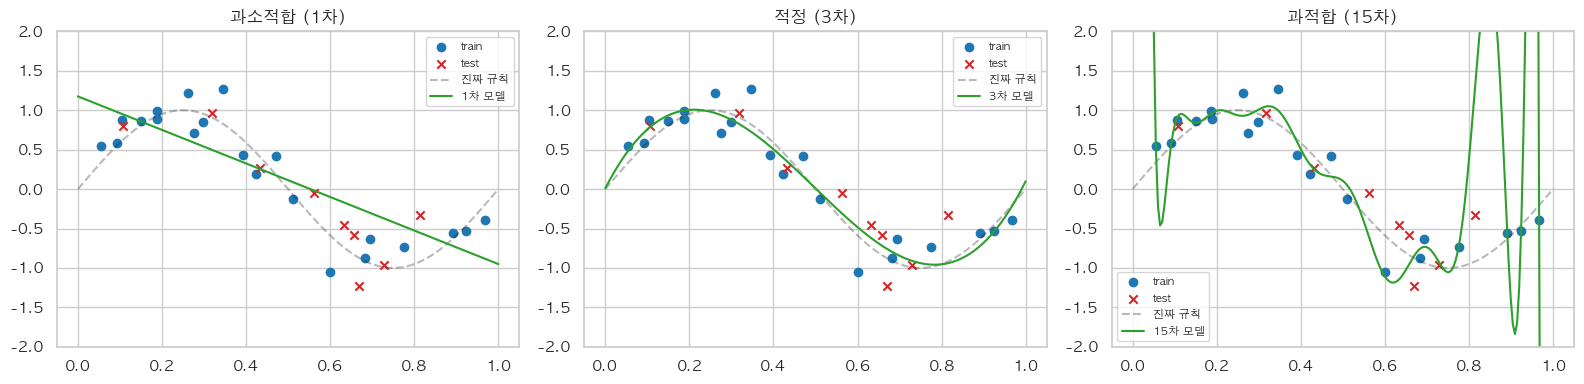

,복잡도(차수),train R²,test R²
0,1,0.68,0.59
1,3,0.90,0.83
2,15,0.96,0.19


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# 진짜 규칙: y = sin(2πx) + 잡음. 모델은 이 규칙을 모른 채 점 30개만 본다.
rng = np.random.default_rng(2)
x_all = np.sort(rng.random(30))
y_all = np.sin(2 * np.pi * x_all) + rng.normal(0, 0.25, size=30)
x_tr, x_te, y_tr, y_te = train_test_split(x_all, y_all, test_size=0.3, random_state=1)

x_line = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
scores = []
for ax, degree in zip(axes, [1, 3, 15]):
  model = make_pipeline(PolynomialFeatures(degree), LinearRegression())   # degree 차 다항식 = 복잡도
  model.fit(x_tr.reshape(-1, 1), y_tr)
  tr, te = model.score(x_tr.reshape(-1, 1), y_tr), model.score(x_te.reshape(-1, 1), y_te)
  scores.append((degree, round(tr, 3), round(te, 3)))
  ax.scatter(x_tr, y_tr, label="train", color="tab:blue")
  ax.scatter(x_te, y_te, label="test", color="tab:red", marker="x")
  ax.plot(x_line, np.sin(2 * np.pi * x_line), "k--", alpha=0.3, label="진짜 규칙")
  ax.plot(x_line, model.predict(x_line.reshape(-1, 1)), color="tab:green", label=f"{degree}차 모델")
  ax.set_ylim(-2, 2)
  ax.set_title({1: "과소적합 (1차)", 3: "적정 (3차)", 15: "과적합 (15차)"}[degree])
  ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(scores, columns=["복잡도(차수)", "train R²", "test R²"])

#### 진단 규칙: train 점수와 test 점수를 **함께** 본다

| train 점수 | test 점수 | 진단 | 대처 |
|:---:|:---:|------|------|
| 낮음 | 낮음 | **과소적합** | 더 복잡한 모델, 파생 변수 추가, 학습 더 오래 |
| 높음 | 낮음 (차이 큼) | **과적합** | 데이터 추가, 규제, 복잡도 낮추기(트리 깊이 제한), 변수 줄이기, 앙상블 |
| 높음 | 높음 (차이 작음) | **적정** | 이 상태를 목표로 |

이것이 4회차에서 데이터를 **train / test 로 나눈 이유** 입니다. test 점수가 없으면 과적합을 알아챌 방법이 없습니다.

> **편향-분산 트레이드오프**: 과소적합은 "편향(bias)이 큼" (한쪽으로 치우친 단순한 추측), 과적합은 "분산(variance)이 큼" (데이터가 조금만 바뀌어도 모델이 크게 흔들림). 둘은 한쪽을 줄이면 다른 쪽이 커지는 관계라 **중간에서 타협** 합니다.

### 1.4 평가지표 미리보기

모델이 "잘 맞힌다" 를 **숫자 하나** 로 표현한 것이 평가지표입니다. 문제 유형에 따라 다르며, 각 절에서 코드와 함께 배웁니다.

| 문제 | 지표 | 좋은 방향 |
|------|------|:---:|
| 회귀 | MAE, MSE, RMSE | 작을수록 |
| 회귀 | R² | 1 에 가까울수록 |

> 회귀 지표(MAE, MSE, RMSE, R²)는 **2.3 절**, 분류 지표(정확도, 정밀도, 재현율, F1, AUC)는 **3.3 절** 에서 예제와 함께 자세히 설명합니다.
| 분류 | 정확도, 정밀도, 재현율, F1, ROC-AUC | 1 에 가까울수록 |

### 📝 시험 출제 포인트 (1장)

- 문항 자체는 코드지만, "적절한 모델을 선택하여" 라는 문구에서 **회귀/분류 판단** 이 핵심. 타깃이 숫자면 `LinearRegression` 계열, 범주면 `LogisticRegression` 계열.
- `fit(X_train, y_train)` → `predict(X_test)` → 지표 함수(`y_test, y_pred`) 순서. **지표 함수의 인자 순서는 (실제값, 예측값)**.
- 과적합 여부를 묻는 문항: train 점수와 test 점수를 둘 다 출력해 비교.

### ⚠️ 자주 하는 실수 (1장)

- **`fit` 에 test 데이터 사용**: `model.fit(X_test, y_test)` 는 시험지를 보고 공부하는 것. 항상 train.
- **`predict` 에 y 를 넣음**: `predict(X_test)` 만. y 는 지표 계산 때만.
- **train 점수만 보고 만족**: 0.99 는 대개 과적합 신호.

---
## 2. 선형회귀 (Linear Regression) — 캘리포니아 주택 가격

### 한 줄 정의
입력 변수들의 **가중합** 으로 숫자를 예측하는 가장 단순한 회귀 모델.

```
주택가격 = w1 × 소득중앙값 + w2 × 주택연식 + … + b
```

### 직관적 설명
산점도에 **점들 사이를 가장 잘 지나가는 직선** 을 긋는 것입니다. "가장 잘" 의 기준은 **각 점에서 직선까지의 세로 거리(오차)의 제곱합이 최소** 가 되는 것 (최소제곱법). 직선의 기울기가 계수(w), 절편이 b 입니다.

### 2.1 데이터 살펴보기 (3회차 복습, 짧게)

In [7]:
housing.describe().T[["mean", "50%", "min", "max"]]

,mean,50%,min,max
경도,-119.56,-118.49,-124.35,-114.31
위도,35.63,34.25,32.54,41.95
주택연식,28.59,29.00,1.00,52.00
총방수,"2,643.66","2,127.00",2.00,"37,937.00"
총침실수,539.41,434.00,1.00,"6,445.00"
인구,"1,429.57","1,167.00",3.00,"35,682.00"
가구수,501.22,409.00,1.00,"6,082.00"
소득중앙값,3.88,3.54,0.50,15.00
주택가격,"207,300.91","180,400.00","14,999.00","500,001.00"


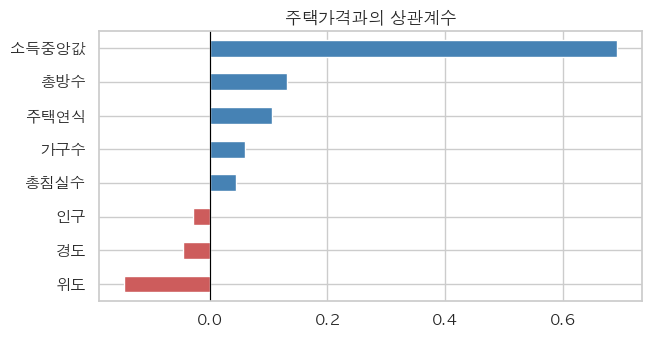

In [8]:
# 타깃과 각 변수의 상관: 소득중앙값이 압도적으로 강하다
corr = housing.corr()["주택가격"].drop("주택가격").sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
corr.plot(kind="barh", ax=ax, color=np.where(corr > 0, "steelblue", "indianred"))
ax.set_title("주택가격과의 상관계수")
ax.axvline(0, color="black", linewidth=0.8)
plt.show()

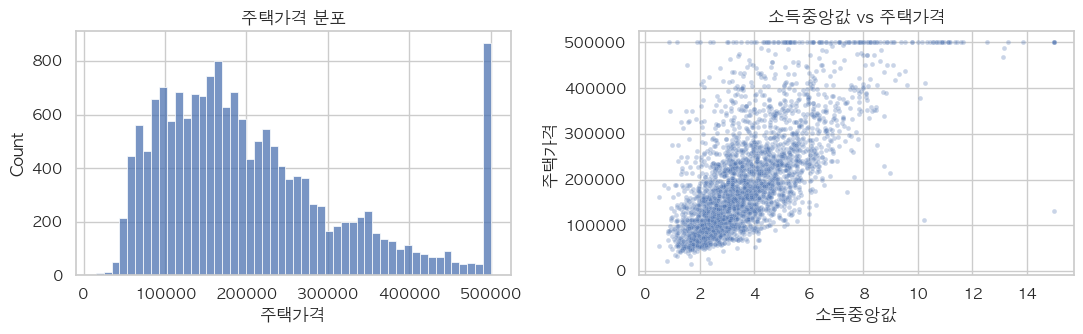

상한(500,001) 에 걸린 구역 수: 836


In [9]:
# 타깃 분포: 500,001 달러에 뾰족한 막대 -> 원본 데이터가 상한으로 잘려(capped) 있다. 모델 오차의 원인 중 하나
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(housing["주택가격"], bins=50, ax=axes[0])
axes[0].set_title("주택가격 분포")
sample = housing.sample(3000, random_state=0)      # 17,000 점은 너무 많아 3,000 개만 표시
sns.scatterplot(data=sample, x="소득중앙값", y="주택가격", alpha=0.3, s=12, ax=axes[1])
axes[1].set_title("소득중앙값 vs 주택가격")
plt.tight_layout()
plt.show()
print("상한(500,001) 에 걸린 구역 수:", (housing["주택가격"] >= 500000).sum())

### 2.2 단순 선형회귀: 변수 하나로 시작

변수 하나(소득중앙값)로 주택가격을 예측하면서 `fit` → `predict` → 계수 해석을 익힙니다.

In [10]:
X = housing[["소득중앙값"]]       # 대괄호 두 개: 2차원 DataFrame (1회차 복습)
y = housing["주택가격"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

w, b = lr.coef_[0], lr.intercept_
print(f"학습된 규칙: 주택가격 = {w:,.0f} × 소득중앙값 + {b:,.0f}")
print(f"해석: 소득중앙값이 1(만 달러) 오르면 주택가격이 약 {w:,.0f} 달러 오른다")

학습된 규칙: 주택가격 = 41,670 × 소득중앙값 + 45,238
해석: 소득중앙값이 1(만 달러) 오르면 주택가격이 약 41,670 달러 오른다


예측값 5개: [195079. 383281. 150613. 221590. 109102.]
실제값 5개: [142700. 500001.  61800. 162800.  90600.]


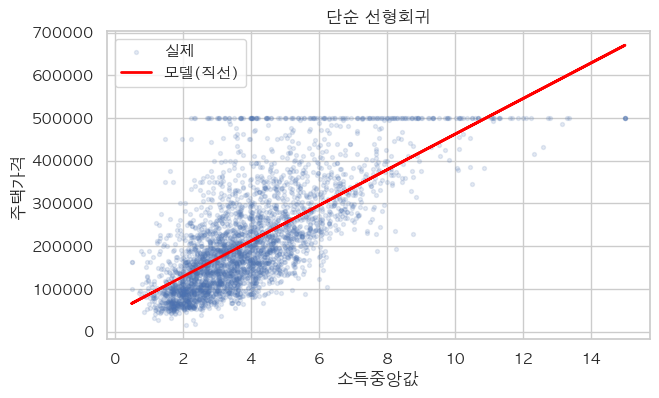

In [11]:
y_pred = lr.predict(X_test)
print("예측값 5개:", y_pred[:5].round(0))
print("실제값 5개:", y_test.values[:5])

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_test, y_test, alpha=0.15, s=8, label="실제")
ax.plot(X_test, y_pred, color="red", linewidth=2, label="모델(직선)")
ax.set_xlabel("소득중앙값")
ax.set_ylabel("주택가격")
ax.set_title("단순 선형회귀")
ax.legend()
plt.show()

### 2.3 회귀 평가지표: MAE, MSE, RMSE, R²

모델이 예측한 숫자가 **실제와 얼마나 가까운지** 를 하나의 점수로 바꾸는 방법입니다. 네 지표 모두 출발점은 같습니다. **"오차(실제 - 예측)"** 를 어떻게 모으느냐만 다릅니다.

#### 2.3.1 출발점: 오차 (error, 잔차 residual)

```
오차 = 실제값 - 예측값
```

- 오차가 **양수** 면 모델이 **작게** 예측한 것(과소 예측), **음수** 면 **크게** 예측한 것(과대 예측)입니다.
- 오차를 그냥 더하면 +와 -가 서로 지워져서 "잘 맞혔다" 고 착각하게 됩니다. 그래서 **부호를 없애는 방법** 이 필요하고, 그 방법에 따라 지표가 갈립니다.

| 부호를 없애는 방법 | 만들어지는 지표 |
|------|------|
| 절댓값을 씌운다 | **MAE** |
| 제곱한다 | **MSE** → 제곱근을 씌우면 **RMSE** |
| 제곱한 뒤 "평균만 찍었을 때" 와 비교한다 | **R²** |

아래는 아파트 5채의 실제 가격과 모델 예측(단위: 억 원)입니다. 이 작은 예로 네 지표를 **손으로** 계산해 봅니다.

In [12]:
example = pd.DataFrame({
  "실제(억)": [3.0, 2.5, 4.0, 3.5, 5.0],
  "예측(억)": [2.8, 2.9, 3.6, 3.5, 4.2],
}, index=["A아파트", "B아파트", "C아파트", "D아파트", "E아파트"])
example["오차"] = example["실제(억)"] - example["예측(억)"]
example["|오차|"] = example["오차"].abs()
example["오차²"] = example["오차"] ** 2

print("오차를 그냥 더하면:", round(example["오차"].sum(), 2), " <- 양수·음수가 일부 지워져 실제보다 작아 보인다")
example.round(3)

오차를 그냥 더하면: 1.0  <- 양수·음수가 일부 지워져 실제보다 작아 보인다


,실제(억),예측(억),오차,|오차|,오차²
A아파트,3.00,2.80,0.20,0.20,0.04
B아파트,2.50,2.90,-0.40,0.40,0.16
C아파트,4.00,3.60,0.40,0.40,0.16
D아파트,3.50,3.50,0.00,0.00,0.00
E아파트,5.00,4.20,0.80,0.80,0.64


#### 2.3.2 MAE (Mean Absolute Error, 평균 절대 오차)

```
MAE = 평균( |실제 - 예측| )
```

- **뜻**: "평균적으로 **몇 억** 빗나갔나." 단위가 목표 변수와 같아서 **설명하기 가장 쉽습니다.**
- **특징**: 1억 빗나간 것은 0.5억 빗나간 것의 정확히 2배로 계산합니다. 큰 오차를 특별히 더 벌주지 않습니다.
- **좋은 값**: 0 에 가까울수록 좋음. 0 이면 완벽.

#### 2.3.3 MSE (Mean Squared Error, 평균 제곱 오차)

```
MSE = 평균( (실제 - 예측)² )
```

- **뜻**: 오차를 **제곱해서** 평균. 0.2억 오차는 0.04, 0.8억 오차는 0.64 가 되어 **큰 오차가 훨씬 크게** 반영됩니다.
- **단점**: 단위가 "억²" 이라 숫자 자체를 해석하기 어렵습니다. 주택가격(달러)이면 수십억 단위의 큰 숫자가 나옵니다.
- **쓰임**: 선형회귀가 **학습할 때 최소화하는 값** 이 바로 이것입니다 (최소제곱법).

#### 2.3.4 RMSE (Root Mean Squared Error, 평균 제곱근 오차)

```
RMSE = √MSE
```

- **뜻**: MSE 에 제곱근을 씌워 **단위를 원래대로(억)** 되돌린 값. "대략 이 정도 빗나간다" 로 읽습니다.
- **특징**: 단위는 MAE 와 같지만, 큰 오차를 더 무겁게 본 결과라 **항상 MAE 보다 크거나 같습니다.**
- 회귀 모델 성능을 보고할 때 **가장 많이 쓰이는 지표** 입니다.

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true_ex = example["실제(억)"]
y_pred_ex = example["예측(억)"]

mae_hand = example["|오차|"].mean()
mse_hand = example["오차²"].mean()
rmse_hand = np.sqrt(mse_hand)

print(f"MAE  손계산 {mae_hand:.4f} | sklearn {mean_absolute_error(y_true_ex, y_pred_ex):.4f}  (단위: 억)")
print(f"MSE  손계산 {mse_hand:.4f} | sklearn {mean_squared_error(y_true_ex, y_pred_ex):.4f}  (단위: 억², 해석 어려움)")
print(f"RMSE 손계산 {rmse_hand:.4f} | sklearn {np.sqrt(mean_squared_error(y_true_ex, y_pred_ex)):.4f}  (단위: 억)")
print("-> RMSE 가 MAE 보다 큰 이유: E아파트의 0.8억 오차가 제곱되어 크게 반영됐기 때문")

MAE  손계산 0.3600 | sklearn 0.3600  (단위: 억)
MSE  손계산 0.2000 | sklearn 0.2000  (단위: 억², 해석 어려움)
RMSE 손계산 0.4472 | sklearn 0.4472  (단위: 억)
-> RMSE 가 MAE 보다 큰 이유: E아파트의 0.8억 오차가 제곱되어 크게 반영됐기 때문


#### 2.3.5 MAE 와 RMSE 는 언제 다르게 말하나

두 모델이 5채를 예측했습니다.

- **모델 A**: 5채 모두 **1억씩** 빗나감 (꾸준히 조금씩 틀림)
- **모델 B**: 4채는 **정확히** 맞히고 1채만 **5억** 빗나감 (가끔 크게 틀림)

In [14]:
actual = np.array([3.0, 2.5, 4.0, 3.5, 5.0])
pred_a = actual + np.array([1, -1, 1, -1, 1])        # 모두 1억씩 오차
pred_b = actual + np.array([0, 0, 0, 0, 5])          # 한 채만 5억 오차

pd.DataFrame({
  "MAE": [mean_absolute_error(actual, pred_a), mean_absolute_error(actual, pred_b)],
  "RMSE": [np.sqrt(mean_squared_error(actual, pred_a)), np.sqrt(mean_squared_error(actual, pred_b))],
}, index=["모델 A (모두 1억씩)", "모델 B (한 채만 5억)"]).round(3)

,MAE,RMSE
모델 A (모두 1억씩),1.00,1.00
모델 B (한 채만 5억),1.00,2.24


- **MAE 는 둘을 똑같이(1.0) 평가** 합니다. 총 빗나간 양이 같기 때문입니다.
- **RMSE 는 모델 B 를 2배 이상 나쁘게** 평가합니다. 한 번의 큰 실수를 무겁게 보기 때문입니다.

| 이런 상황이라면 | 볼 지표 |
|------|------|
| 한 번의 큰 실수가 치명적 (재고 예측, 대출 한도) | **RMSE** |
| 데이터에 이상치가 많아 몇 개에 휘둘리고 싶지 않음 | **MAE** |
| 결과를 비전공자에게 설명해야 함 ("평균 3천만 원 정도 틀린다") | **MAE** |

#### 2.3.6 R² (결정계수, R-squared)

MAE·RMSE 는 "몇 억 틀렸나" 를 말하지만, **그게 잘한 건지 못한 건지** 는 알려 주지 않습니다. 1억 오차는 10억짜리 집에선 작고 2억짜리 집에선 큽니다. R² 는 **가장 단순한 예측(모두에게 평균값을 찍기)과 비교** 해서 점수를 매깁니다.

```
              모델의 오차² 합            ← 모델이 남긴 오차
R² = 1 -  ───────────────────────
           평균으로 찍었을 때의 오차² 합   ← 아무 정보 없이 평균만 썼을 때의 오차
```

| R² 값 | 뜻 |
|:---:|------|
| **1** | 완벽한 예측 (오차 0) |
| **0.7** | 평균만 찍을 때의 오차를 **70% 줄였다** = "가격 변동의 70% 를 설명한다" |
| **0** | 평균만 찍는 것과 같은 수준 (모델이 쓸모없음) |
| **음수** | **평균만 찍는 것보다도 못함** (무언가 잘못됨) |

- **단위가 없어서** 서로 다른 데이터(집값, 키, 매출)의 모델도 같은 기준으로 비교할 수 있습니다.
- 선형회귀의 `model.score(X, y)` 가 돌려주는 값이 바로 R² 입니다.

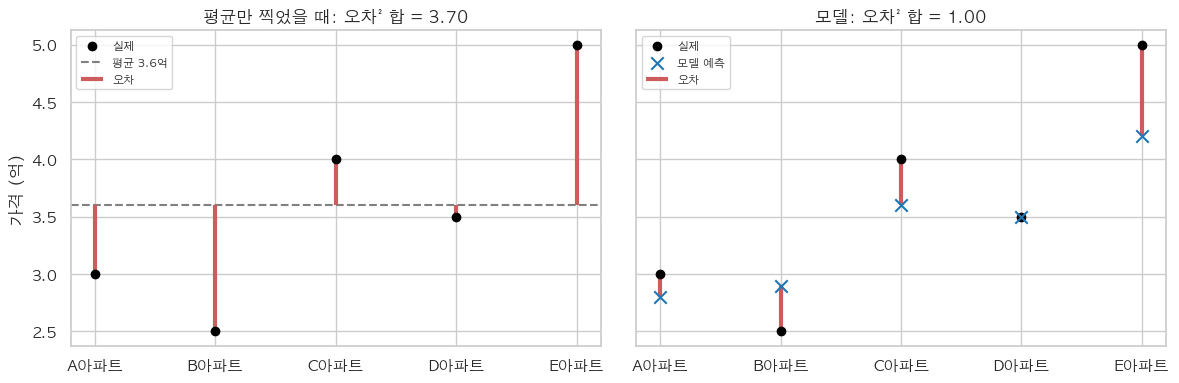

R² = 1 - 1.00 / 3.70 = 0.7297
sklearn r2_score = 0.7297
-> 평균만 찍을 때의 오차를 약 73% 줄였다


In [15]:
# R² 를 그림으로: 왼쪽 = 평균만 찍었을 때의 오차, 오른쪽 = 모델의 오차
mean_line = y_true_ex.mean()
sst = ((y_true_ex - mean_line) ** 2).sum()          # 평균으로 찍었을 때의 오차² 합
sse = ((y_true_ex - y_pred_ex) ** 2).sum()          # 모델의 오차² 합

xs = np.arange(len(y_true_ex))
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].scatter(xs, y_true_ex, color="black", zorder=3, label="실제")
axes[0].axhline(mean_line, color="gray", linestyle="--", label=f"평균 {mean_line:.1f}억")
axes[0].vlines(xs, mean_line, y_true_ex, color="indianred", linewidth=3, label="오차")
axes[0].set_title(f"평균만 찍었을 때: 오차² 합 = {sst:.2f}")

axes[1].scatter(xs, y_true_ex, color="black", zorder=3, label="실제")
axes[1].scatter(xs, y_pred_ex, color="tab:blue", marker="x", s=80, zorder=3, label="모델 예측")
axes[1].vlines(xs, y_pred_ex, y_true_ex, color="indianred", linewidth=3, label="오차")
axes[1].set_title(f"모델: 오차² 합 = {sse:.2f}")

for ax in axes:
  ax.set_xticks(xs, labels=example.index)
  ax.legend(fontsize=8)
axes[0].set_ylabel("가격 (억)")
plt.tight_layout()
plt.show()

print(f"R² = 1 - {sse:.2f} / {sst:.2f} = {1 - sse / sst:.4f}")
print(f"sklearn r2_score = {r2_score(y_true_ex, y_pred_ex):.4f}")
print(f"-> 평균만 찍을 때의 오차를 약 {(1 - sse / sst) * 100:.0f}% 줄였다")

빨간 막대(오차)가 오른쪽에서 훨씬 짧아졌습니다. R² 는 **"빨간 막대를 얼마나 줄였나"** 를 0~1 사이 비율로 나타낸 것입니다.

#### 2.3.7 한눈에 비교

| 지표 | 한 줄 뜻 | 단위 | 좋은 값 | 큰 오차에 | 이럴 때 쓴다 |
|------|------|:---:|:---:|:---:|------|
| **MAE** | 평균적으로 얼마나 빗나갔나 | 목표와 같음 | 0 에 가까울수록 | 보통 | 설명이 쉬워야 할 때, 이상치가 많을 때 |
| **MSE** | 오차 제곱의 평균 | 목표² | 0 에 가까울수록 | 매우 민감 | 모델 학습 내부 (보고용으로는 잘 안 씀) |
| **RMSE** | MSE 를 원래 단위로 | 목표와 같음 | 0 에 가까울수록 | 민감 | **가장 일반적인 보고 지표**, 큰 실수가 치명적일 때 |
| **R²** | 평균 대비 오차를 몇 % 줄였나 | 없음 | 1 에 가까울수록 | 민감 | 모델이 **쓸모 있는지** 판단, 다른 데이터 간 비교 |

> 실무와 시험에서는 보통 **RMSE(얼마나 틀리나) + R²(얼마나 설명하나)** 를 함께 적습니다. 하나는 크기, 하나는 비율이라 서로 보완합니다.

#### 2.3.8 scikit-learn 함수

| 지표 | 함수 | 비고 |
|------|------|------|
| MAE | `mean_absolute_error(y_true, y_pred)` | |
| MSE | `mean_squared_error(y_true, y_pred)` | |
| RMSE | `np.sqrt(mean_squared_error(y_true, y_pred))` | 어느 버전에서나 동작 (가장 안전) |
| RMSE | `root_mean_squared_error(y_true, y_pred)` | scikit-learn 1.4 이상 |
| R² | `r2_score(y_true, y_pred)` 또는 `model.score(X, y)` | |

> 인자 순서는 항상 **(실제값, 예측값)** 입니다. MAE·MSE·RMSE 는 순서를 바꿔도 값이 같지만 **R² 는 달라지므로** 습관을 들여야 합니다.

#### 2.3.9 실제 모델에 적용하기

이제 위 단순 선형회귀(소득중앙값 → 주택가격)를 네 지표로 평가합니다. 단위는 **달러** 입니다.

In [16]:
def regression_report(y_true, y_pred, name: str = "") -> dict:
  mse = mean_squared_error(y_true, y_pred)
  return {
    "모델": name,
    "MAE": int(round(mean_absolute_error(y_true, y_pred))),
    "MSE": int(round(mse)),
    "RMSE": int(round(np.sqrt(mse))),
    "R2": round(r2_score(y_true, y_pred), 4),
  }


results = [regression_report(y_test, y_pred, "단순회귀(소득)")]
pd.DataFrame(results)

,모델,MAE,MSE,RMSE,R2
0,단순회귀(소득),62164,6920028496,83187,0.50


**읽는 법**: MAE 가 약 6만 2천 달러, RMSE 가 약 8만 3천 달러입니다. "이 모델은 구역 주택가격을 평균 6만 달러 정도 틀리고, 큰 오차까지 감안하면 8만 달러 정도 틀린다" 로 읽습니다. RMSE 가 MAE 보다 꽤 크므로 **가끔 크게 빗나가는 구역이 있다** 는 뜻이기도 합니다. R² 약 0.5 는 "평균만 찍었을 때의 오차를 절반 정도 줄였다" 입니다. MSE 는 수십억 단위라 해석에 쓰지 않습니다.

In [17]:
# 지표의 의미를 손으로 확인: 평균으로만 예측하면 R² 가 0 이 된다
baseline = np.full(len(y_test), y_train.mean())
print("평균으로 예측한 RMSE:", round(np.sqrt(mean_squared_error(y_test, baseline))), "| R²:", round(r2_score(y_test, baseline), 4))
print("모델 score() = R²  :", round(lr.score(X_test, y_test), 4), " <- score() 는 회귀에서 R² 를 돌려준다")

평균으로 예측한 RMSE: 117421 | R²: -0.0006
모델 score() = R²  : 0.4978  <- score() 는 회귀에서 R² 를 돌려준다


### 2.4 다중 선형회귀: 변수 여러 개

변수를 더 넣으면 얼마나 좋아지는지 확인합니다. 4회차 전처리 흐름을 그대로 따릅니다: **파생 변수 → 분할 → 스케일링 → 학습 → 평가**.

파생 변수 3개는 "구역 전체 합계" 를 "가구당 값" 으로 바꾼 것입니다. 큰 구역과 작은 구역을 비교할 수 있게 해 줍니다.

In [18]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
  out = df.copy()
  out["가구당방수"] = out["총방수"] / out["가구수"]
  out["침실비율"] = out["총침실수"] / out["총방수"]
  out["가구당인구"] = out["인구"] / out["가구수"]
  return out


housing_fe = add_features(housing)
X = housing_fe.drop(columns=["주택가격"])
y = housing_fe["주택가격"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("특징 수:", X_train.shape[1], "| 컬럼:", X_train.columns.tolist())

특징 수: 11 | 컬럼: ['경도', '위도', '주택연식', '총방수', '총침실수', '인구', '가구수', '소득중앙값', '가구당방수', '침실비율', '가구당인구']


In [19]:
# 스케일링: 선형회귀는 스케일링 없이도 예측값은 같지만, 계수 크기를 서로 비교하려면 필요하다
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

mlr = LinearRegression()
mlr.fit(X_train_s, y_train)
y_pred_m = mlr.predict(X_test_s)

results.append(regression_report(y_test, y_pred_m, "다중회귀(전체+파생)"))
pd.DataFrame(results)

,모델,MAE,MSE,RMSE,R2
0,단순회귀(소득),62164,6920028496,83187,0.50
1,다중회귀(전체+파생),49206,4552463038,67472,0.67


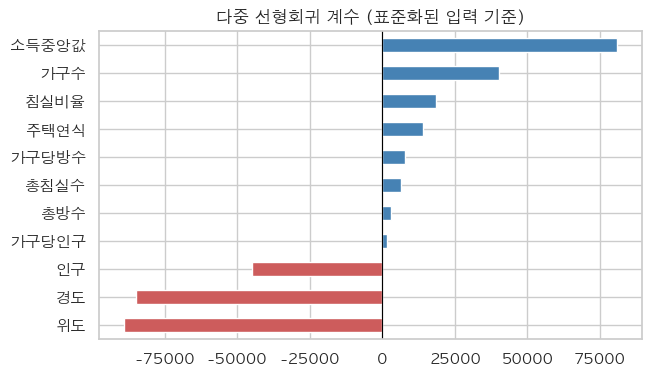

절편: 206708 (모든 입력이 평균일 때의 예측값 ≈ 타깃 평균)


In [20]:
# 계수 해석: 스케일링했으므로 절댓값이 클수록 영향이 큰 변수
coef = pd.Series(mlr.coef_, index=X_train.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
coef.plot(kind="barh", ax=ax, color=np.where(coef > 0, "steelblue", "indianred"))
ax.set_title("다중 선형회귀 계수 (표준화된 입력 기준)")
ax.axvline(0, color="black", linewidth=0.8)
plt.show()
print("절편:", round(mlr.intercept_), "(모든 입력이 평균일 때의 예측값 ≈ 타깃 평균)")

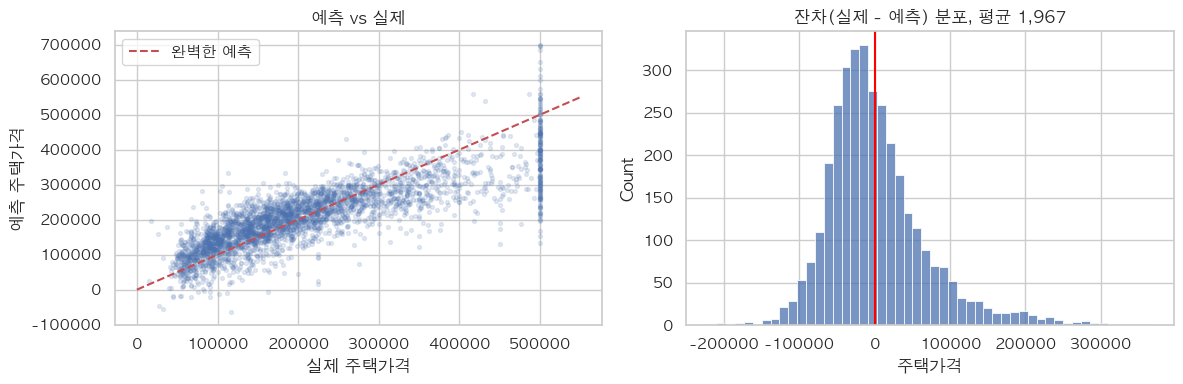

In [21]:
# 예측 vs 실제: 대각선에 가까울수록 좋다. 500,001 상한에서 가로줄이 생기는 것이 보인다
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, y_pred_m, alpha=0.15, s=8)
lim = [0, 550000]
axes[0].plot(lim, lim, "r--", label="완벽한 예측")
axes[0].set_xlabel("실제 주택가격")
axes[0].set_ylabel("예측 주택가격")
axes[0].set_title("예측 vs 실제")
axes[0].legend()

residual = y_test - y_pred_m
sns.histplot(residual, bins=50, ax=axes[1])
axes[1].axvline(0, color="red")
axes[1].set_title(f"잔차(실제 - 예측) 분포, 평균 {residual.mean():,.0f}")
plt.tight_layout()
plt.show()

In [22]:
# 과적합 진단: train 과 test 의 R² 비교
print("train R²:", round(mlr.score(X_train_s, y_train), 4))
print("test  R²:", round(mlr.score(X_test_s, y_test), 4))
print("-> 두 값이 비슷하고 둘 다 높지 않다 = 과적합은 아니고, 선형 모델의 한계(과소적합 쪽). 6회차 트리 모델로 개선해 본다.")

train R²: 0.6463
test  R²: 0.6696
-> 두 값이 비슷하고 둘 다 높지 않다 = 과적합은 아니고, 선형 모델의 한계(과소적합 쪽). 6회차 트리 모델로 개선해 본다.


### 2.5 별도 테스트 파일로 최종 확인

`california_housing_test.csv` 는 학습에 전혀 쓰지 않은 **진짜 새 데이터** 입니다. 실무의 "배포 후 성능" 과 같은 의미이며, 반드시 **train 에서 fit 한 스케일러** 로 변환합니다.

In [23]:
X_final = add_features(housing_test).drop(columns=["주택가격"])
y_final = housing_test["주택가격"]
X_final_s = pd.DataFrame(scaler.transform(X_final), columns=X_final.columns)   # transform 만!

y_final_pred = mlr.predict(X_final_s)
pd.DataFrame([regression_report(y_final, y_final_pred, "별도 테스트 파일 (3,000행)")])

,모델,MAE,MSE,RMSE,R2
0,"별도 테스트 파일 (3,000행)",49515,4746252597,68893,0.63


### 📝 시험 출제 포인트 (2장)

- "선형회귀 모델을 학습시키고 `y_pred` 를 구하시오" → `LinearRegression().fit(X_train, y_train)`, `predict(X_test)`
- "RMSE 를 구하시오" → `np.sqrt(mean_squared_error(y_test, y_pred))` (sklearn 버전에 따라 `root_mean_squared_error` 도 있음)
- "R² 를 구하시오" → `r2_score(y_test, y_pred)` 또는 `model.score(X_test, y_test)`
- "회귀 계수와 절편 출력" → `model.coef_`, `model.intercept_`
- 지표 함수 인자 순서: **`(y_test, y_pred)`**

### ⚠️ 자주 하는 실수 (2장)

- **MSE 를 RMSE 로 보고**: 단위가 제곱이라 값이 엄청나게 큽니다. 제곱근을 씌우세요.
- **R² 가 음수**: 모델이 평균보다 못하다는 뜻. 대개 X/y 가 잘못 짝지어졌거나 스케일러를 test 에 fit 한 경우.
- **1차원 X**: `housing["소득중앙값"]` (Series) 를 넣으면 `ValueError: Expected 2D array`. `[["소득중앙값"]]`.
- **계수 크기로 중요도 판단할 때 스케일링 안 함**: 단위가 다르면 계수 크기를 비교할 수 없습니다.

---
## 3. 로지스틱 회귀 (Logistic Regression) — 타이타닉 생존 예측

### 한 줄 정의
선형회귀의 출력을 **0 ~ 1 사이 확률** 로 눌러서 **분류** 에 쓰는 모델. 이름에 "회귀" 가 있지만 **분류 모델** 입니다.

### 직관적 설명
선형회귀로 "생존 여부(0/1)" 를 예측하면 −0.3 이나 1.4 같은 값이 나와 확률로 쓸 수 없습니다. 그래서 출력을 **S 자 곡선(시그모이드)** 에 통과시켜 0~1 로 만듭니다. 그 값이 "생존 확률" 이고, **0.5 보다 크면 생존(1), 작으면 사망(0)** 으로 판정합니다.

```
z = w1·x1 + w2·x2 + … + b        (선형회귀와 같은 부분)
p = 1 / (1 + e^(−z))              (시그모이드: z 를 0~1 확률로)
예측 = 1 if p >= 0.5 else 0        (임계값 0.5 는 바꿀 수 있다)
```

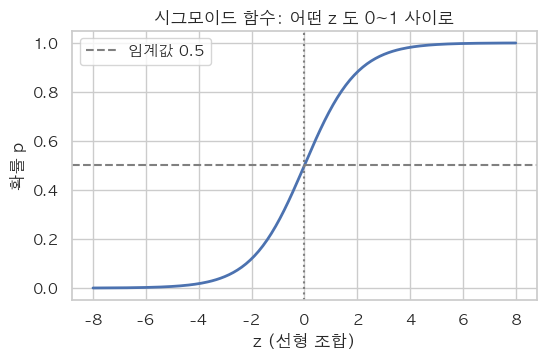

In [24]:
z = np.linspace(-8, 8, 200)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(z, sigmoid, linewidth=2)
ax.axhline(0.5, color="gray", linestyle="--", label="임계값 0.5")
ax.axvline(0, color="gray", linestyle=":")
ax.set_xlabel("z (선형 조합)")
ax.set_ylabel("확률 p")
ax.set_title("시그모이드 함수: 어떤 z 도 0~1 사이로")
ax.legend()
plt.show()

### 3.1 전처리 (4회차 복습, 압축판)

타이타닉 데이터는 **시험 문제와 거의 같은 형태** 입니다: 결측치, 문자열, 쓸모없는 ID 컬럼이 섞여 있습니다.

In [25]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   승객ID     891 non-null    int64  
 1   생존       891 non-null    int64  
 2   객실등급     891 non-null    int64  
 3   이름       891 non-null    object 
 4   성별       891 non-null    object 
 5   나이       714 non-null    float64
 6   동반형제배우자  891 non-null    int64  
 7   동반부모자녀   891 non-null    int64  
 8   티켓번호     891 non-null    object 
 9   운임       891 non-null    float64
 10  객실번호     204 non-null    object 
 11  탑승항구     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [26]:
# 결측 확인: 나이 177, 객실번호 687(77%), 탑승항구 2
missing = titanic.isnull().sum()
print(missing[missing > 0])

나이      177
객실번호    687
탑승항구      2
dtype: int64


In [27]:
def preprocess_titanic(df: pd.DataFrame, train_stats: dict | None = None) -> tuple[pd.DataFrame, dict]:
  '''타이타닉 전처리. train_stats 를 주면 그 통계(train 기준)로 결측을 채운다 (test 파일용).'''
  out = df.copy()
  stats = train_stats or {
    "나이_중앙값": out["나이"].median(),
    "운임_중앙값": out["운임"].median(),
    "탑승항구_최빈값": out["탑승항구"].mode()[0],
  }
  # 1) 불필요 컬럼: ID·이름·티켓은 예측에 무의미, 객실번호는 77% 결측
  out = out.drop(columns=["승객ID", "이름", "티켓번호", "객실번호"])
  # 2) 결측치
  out["나이"] = out["나이"].fillna(stats["나이_중앙값"])
  out["운임"] = out["운임"].fillna(stats["운임_중앙값"])
  out["탑승항구"] = out["탑승항구"].fillna(stats["탑승항구_최빈값"])
  # 3) 파생 변수: 가족 수, 혼자 탑승 여부
  out["가족수"] = out["동반형제배우자"] + out["동반부모자녀"] + 1
  out["혼자탑승"] = (out["가족수"] == 1).astype(int)
  # 4) 인코딩: 성별 이진 map, 탑승항구 원-핫
  out["성별"] = out["성별"].map({"male": 0, "female": 1})
  out = pd.get_dummies(out, columns=["탑승항구"], drop_first=True, dtype=int)
  return out, stats


titanic_clean, train_stats = preprocess_titanic(titanic)
print(titanic_clean.shape, "| 결측:", titanic_clean.isnull().sum().sum(), "| 문자열:", titanic_clean.select_dtypes("object").shape[1])
print("train 통계:", train_stats)
titanic_clean.head(3)

(891, 11) | 결측: 0 | 문자열: 0
train 통계: {'나이_중앙값': 28.0, '운임_중앙값': 14.4542, '탑승항구_최빈값': 'S'}


,생존,객실등급,성별,나이,동반형제배우자,동반부모자녀,운임,가족수,혼자탑승,탑승항구_Q,탑승항구_S
0,0,3,0,22.00,1,0,7.25,2,0,0,1
1,1,1,1,38.00,1,0,71.28,2,0,0,0
2,1,3,1,26.00,0,0,7.92,1,1,0,1


In [28]:
X = titanic_clean.drop(columns=["생존"])
y = titanic_clean["생존"]
print("생존 비율:", y.value_counts(normalize=True).round(3).to_dict(), " <- 약 38:62, 약간 불균형")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
print("train:", X_train_s.shape, "| test:", X_test_s.shape)

생존 비율: {0: 0.616, 1: 0.384}  <- 약 38:62, 약간 불균형
train: (712, 10) | test: (179, 10)


### 3.2 학습과 예측

In [29]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)                 # 0 또는 1
y_proba = clf.predict_proba(X_test_s)[:, 1]    # [:, 1] = 클래스 1(생존) 확률

compare = pd.DataFrame({"실제": y_test.values[:8], "생존확률": y_proba[:8].round(3), "예측": y_pred[:8]})
compare

,실제,생존확률,예측
0,0,0.08,0
1,0,0.07,0
2,1,0.14,0
3,0,0.04,0
4,1,0.76,1
5,1,0.53,1
6,1,0.73,1
7,0,0.30,0


In [30]:
print("predict_proba 의 모양:", clf.predict_proba(X_test_s).shape, " <- (행 수, 클래스 수). 각 행의 합은 1")
print("클래스 순서:", clf.classes_)
print("정확도 (score):", round(clf.score(X_test_s, y_test), 4))

predict_proba 의 모양: (179, 2)  <- (행 수, 클래스 수). 각 행의 합은 1
클래스 순서: [0 1]
정확도 (score): 0.8045


### 3.3 분류 평가지표

#### 혼동행렬 (Confusion Matrix)

|  | 예측: 사망(0) | 예측: 생존(1) |
|------|:---:|:---:|
| **실제: 사망(0)** | TN (맞음) | **FP** (거짓 경보) |
| **실제: 생존(1)** | **FN** (놓침) | TP (맞음) |

| 지표 | 계산 | 질문 | 언제 중요 |
|------|------|------|------|
| **정확도** Accuracy | (TP+TN) / 전체 | 전체 중 맞힌 비율 | 클래스가 균형일 때 |
| **정밀도** Precision | TP / (TP+FP) | "생존이라 한 것 중 진짜 생존은?" | 거짓 경보 비용이 클 때 (스팸 분류: 정상 메일을 스팸으로 하면 안 됨) |
| **재현율** Recall | TP / (TP+FN) | "진짜 생존자 중 얼마나 찾았나?" | 놓치는 비용이 클 때 (암 진단, 이탈 고객 탐지) |
| **F1** | 정밀도·재현율의 조화평균 | 둘의 균형 | 불균형 데이터의 기본 지표 |

> **정확도의 함정**: 이탈률 5% 데이터에서 "전부 이탈 안 함" 으로 찍으면 정확도 95% 입니다. 불균형이면 반드시 정밀도·재현율·F1 을 봅니다.

혼동행렬:
 [[97 13]
 [22 47]]
TN=97, FP=13, FN=22, TP=47


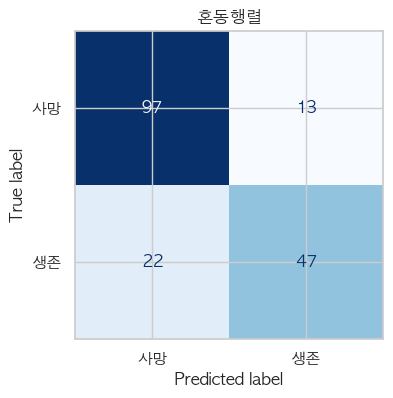

In [31]:
from sklearn.metrics import (
  confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
  recall_score, f1_score, classification_report, roc_auc_score, RocCurveDisplay,
)

cm = confusion_matrix(y_test, y_pred)
print("혼동행렬:\n", cm)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["사망", "생존"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("혼동행렬")
plt.show()

In [32]:
# 지표를 손으로 계산한 것과 sklearn 함수가 일치하는지 확인
print(f"정확도  수식 {(tp + tn) / (tp + tn + fp + fn):.4f} | sklearn {accuracy_score(y_test, y_pred):.4f}")
print(f"정밀도  수식 {tp / (tp + fp):.4f} | sklearn {precision_score(y_test, y_pred):.4f}")
print(f"재현율  수식 {tp / (tp + fn):.4f} | sklearn {recall_score(y_test, y_pred):.4f}")
p, r = precision_score(y_test, y_pred), recall_score(y_test, y_pred)
print(f"F1     수식 {2 * p * r / (p + r):.4f} | sklearn {f1_score(y_test, y_pred):.4f}")

정확도  수식 0.8045 | sklearn 0.8045
정밀도  수식 0.7833 | sklearn 0.7833
재현율  수식 0.6812 | sklearn 0.6812
F1     수식 0.7287 | sklearn 0.7287


In [33]:
# 한 번에 보기: classification_report (클래스별 정밀도·재현율·F1 + 평균)
print(classification_report(y_test, y_pred, target_names=["사망(0)", "생존(1)"]))

              precision    recall  f1-score   support

       사망(0)       0.82      0.88      0.85       110
       생존(1)       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



#### ROC 곡선과 AUC

임계값을 0 → 1 로 바꿔 가며 **(거짓 양성 비율, 재현율)** 을 찍은 곡선이 ROC, 그 아래 면적이 **AUC** 입니다.

| AUC | 의미 |
|:---:|------|
| 1.0 | 완벽하게 구분 |
| 0.5 | 동전 던지기 (대각선) |
| 0.8 이상 | 보통 "좋은 모델" |

AUC 는 **임계값에 무관** 하고 **확률(`predict_proba`)** 로 계산하므로, 모델끼리 비교할 때 가장 공정한 지표입니다.

ROC-AUC: 0.8502


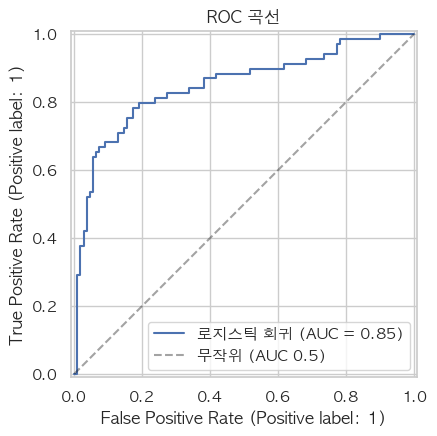

In [34]:
auc = roc_auc_score(y_test, y_proba)      # 주의: y_pred(0/1) 가 아니라 y_proba(확률)!
print("ROC-AUC:", round(auc, 4))

fig, ax = plt.subplots(figsize=(5, 4.5))
RocCurveDisplay.from_predictions(y_test, y_proba, name="로지스틱 회귀", ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="무작위 (AUC 0.5)")
ax.set_title("ROC 곡선")
ax.legend()
plt.show()

### 3.4 임계값 조정: 정밀도와 재현율의 줄다리기

`predict()` 는 0.5 를 기준으로 자르지만, **목적에 따라 기준을 바꿀 수 있습니다.** 구조 우선순위를 정하는 문제라면 "생존 가능성이 30% 만 돼도 생존으로 분류" 하는 편이 나을 수 있습니다.

In [35]:
rows = []
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
  pred_th = (y_proba >= th).astype(int)
  rows.append({
    "임계값": th,
    "생존 예측 수": pred_th.sum(),
    "정밀도": round(precision_score(y_test, pred_th), 3),
    "재현율": round(recall_score(y_test, pred_th), 3),
    "F1": round(f1_score(y_test, pred_th), 3),
  })
pd.DataFrame(rows)

,임계값,생존 예측 수,정밀도,재현율,F1
0,0.30,83,0.68,0.81,0.74
1,0.40,71,0.73,0.75,0.74
2,0.50,60,0.78,0.68,0.73
3,0.60,50,0.88,0.64,0.74
4,0.70,42,0.88,0.54,0.67


임계값을 **낮추면** 생존 예측이 늘어 재현율↑ 정밀도↓, **높이면** 그 반대입니다. 둘을 동시에 올릴 수는 없고, 문제의 비용 구조에 따라 고릅니다.

### 3.5 계수 해석: 무엇이 생존을 갈랐나

로지스틱 회귀의 계수는 "그 변수가 1 표준편차 커지면 **생존 확률의 승산(odds)** 이 e^계수 배가 된다" 로 읽습니다. 부호만 봐도 방향을 알 수 있습니다.

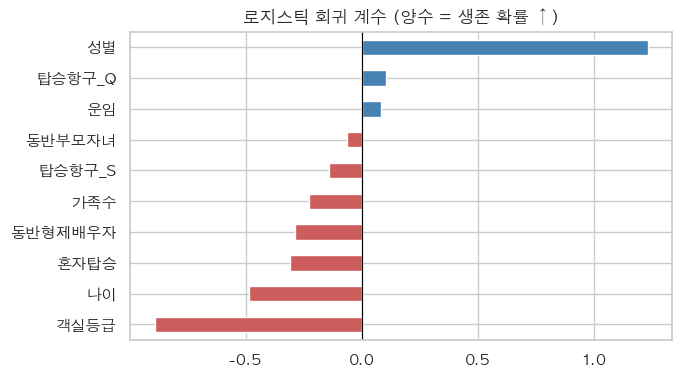

,계수,승산비 e^계수
성별,1.23,3.43
탑승항구_Q,0.11,1.11
운임,0.09,1.09
동반부모자녀,-0.06,0.94
탑승항구_S,-0.14,0.87
가족수,-0.23,0.80
동반형제배우자,-0.29,0.75
혼자탑승,-0.31,0.73
나이,-0.49,0.61
객실등급,-0.89,0.41


In [36]:
coef = pd.Series(clf.coef_[0], index=X_train.columns).sort_values()
odds = np.exp(coef)

fig, ax = plt.subplots(figsize=(7, 4))
coef.plot(kind="barh", ax=ax, color=np.where(coef > 0, "steelblue", "indianred"))
ax.set_title("로지스틱 회귀 계수 (양수 = 생존 확률 ↑)")
ax.axvline(0, color="black", linewidth=0.8)
plt.show()

pd.DataFrame({"계수": coef.round(3), "승산비 e^계수": odds.round(2)}).sort_values("계수", ascending=False)

- **성별** 계수가 가장 크고 양수(여성 = 1): "여성과 아이 먼저" 가 데이터에 그대로 남아 있습니다.
- **객실등급** 은 음수: 등급 숫자가 커질수록(3등석) 생존 확률이 낮습니다.
- **나이** 음수: 어릴수록 생존에 유리.

### 3.6 별도 테스트 파일 예측과 제출 파일 만들기

`titanic_test.csv` 에는 정답(`생존`)이 없습니다. **train 의 통계로 전처리** 하고 예측한 뒤, 시험·대회에서 요구하는 형식(`승객ID`, `생존`)으로 저장합니다.

In [37]:
test_clean, _ = preprocess_titanic(titanic_test, train_stats=train_stats)   # train 통계로 결측 대체
test_clean = test_clean.reindex(columns=X_train.columns, fill_value=0)       # 컬럼 순서·구성을 train 과 동일하게
test_s = pd.DataFrame(scaler.transform(test_clean), columns=test_clean.columns)

submission = pd.DataFrame({"승객ID": titanic_test["승객ID"], "생존": clf.predict(test_s)})
submission.to_csv(f"{DATA_DIR}/titanic_submission.csv", index=False)
print("예측 생존 비율:", round(submission["생존"].mean(), 3))
submission.head()

예측 생존 비율: 0.373


,승객ID,생존
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


> `reindex(columns=X_train.columns, fill_value=0)` 은 test 에 없는 원-핫 컬럼을 0 으로 채우고 순서를 맞춥니다. train/test 를 따로 `get_dummies` 할 때 생기는 **컬럼 불일치** 를 막는 관용구입니다. (4회차 ⚠️ 참고)

### 📝 시험 출제 포인트 (3장)

- "로지스틱 회귀로 학습하고 정확도를 출력" → `LogisticRegression().fit(X_train, y_train)`, `accuracy_score(y_test, y_pred)`
- "혼동행렬을 출력" → `confusion_matrix(y_test, y_pred)`
- "정밀도, 재현율, F1 을 출력" → `precision_score`, `recall_score`, `f1_score` 또는 `classification_report`
- "ROC-AUC" → `roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])`
- "생존 확률 출력" → `predict_proba(X_test)[:, 1]`
- 불균형 데이터에서 "적절한 지표" 를 고르라면 **F1 또는 재현율**

### ⚠️ 자주 하는 실수 (3장)

- **AUC 에 `y_pred` 를 넣음**: 확률이 아니라 0/1 을 넣으면 AUC 가 과소 계산됩니다. `predict_proba(...)[:, 1]`.
- **`predict_proba` 의 `[:, 0]` 사용**: 0열은 클래스 0(사망) 확률. 양성 클래스는 **1열**.
- **`ConvergenceWarning`**: 스케일링을 안 했거나 반복이 부족. 스케일링 + `max_iter=1000`.
- **정확도만 보고 판단**: 불균형이면 무의미할 수 있습니다. 혼동행렬을 같이 봅니다.
- **`LogisticRegression` 을 회귀 문제에 사용**: 이름에 속지 마세요. 분류 전용.

---
## 4. 종합 실습

두 데이터를 다시 읽어 AICE 형식으로 진행합니다. 변수명은 지정된 대로 사용하세요.

In [38]:
housing = pd.read_csv(f"{DATA_DIR}/california_housing_train.csv").rename(columns=HOUSING_COLS)
titanic = pd.read_csv(f"{DATA_DIR}/titanic_train.csv").rename(columns=TITANIC_COLS)
print(housing.shape, titanic.shape)

(17000, 9) (891, 12)


### 문제 1. 단순 선형회귀

`housing` 에서 `주택연식` 하나로 `주택가격` 을 예측하는 선형회귀 모델 `lr1` 을 만드시오. 8:2 분할, `random_state=0`. test 의 RMSE 와 R² 를 소수 넷째 자리까지 출력하고, 소득중앙값 모델(2.2절)과 비교해 어느 변수가 더 유용한지 한 줄로 적으시오.

In [39]:
# 여기에 코드를 작성하세요
lr1 = None

<details>
<summary>정답 보기</summary>

```python
X = housing[["주택연식"]]
y = housing["주택가격"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
lr1 = LinearRegression().fit(X_train, y_train)
y_pred = lr1.predict(X_test)
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
print("R²  :", round(r2_score(y_test, y_pred), 4))
# R² 가 0.01 수준으로 소득중앙값(약 0.47)보다 훨씬 낮다 -> 주택연식만으로는 가격을 거의 설명 못 한다
```

</details>

### 문제 2. 다중 선형회귀 + 스케일링

`housing` 의 모든 변수(파생 변수 없이)로 `주택가격` 을 예측하시오. 8:2 분할(`random_state=0`) 후 `StandardScaler` 를 적용(`X_train_scaled`, `X_test_scaled`)하고, 모델 `lr2` 의 train R² 와 test R² 를 출력하시오. 과적합인지 판단하시오.

In [40]:
# 여기에 코드를 작성하세요
lr2 = None

<details>
<summary>정답 보기</summary>

```python
X = housing.drop(columns=["주택가격"])
y = housing["주택가격"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
lr2 = LinearRegression().fit(X_train_scaled, y_train)
print("train R²:", round(lr2.score(X_train_scaled, y_train), 4))
print("test  R²:", round(lr2.score(X_test_scaled, y_test), 4))
# 두 값이 거의 같으므로 과적합이 아니다 (선형 모델의 한계로 둘 다 0.64 안팎)
```

</details>

### 문제 3. 계수 확인

문제 2 의 `lr2` 에서 계수의 절댓값이 가장 큰 변수 이름과 그 계수를 출력하시오.

In [41]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
coef = pd.Series(lr2.coef_, index=X.columns)
top = coef.abs().idxmax()
print(top, round(coef[top], 2))
```

</details>

### 문제 4. 타이타닉 전처리 + 로지스틱 회귀

`titanic` 에 대해 다음을 수행하시오.
1. `승객ID`, `이름`, `티켓번호`, `객실번호` 삭제
2. `나이` 결측은 중앙값, `탑승항구` 결측은 최빈값으로 대체
3. `성별` 을 male=0, female=1 로 변환, `탑승항구` 를 원-핫 인코딩(`drop_first=True`)
4. `생존` 을 `y`, 나머지를 `X` 로 하여 7:3 분할 (`random_state=42`, `stratify=y`)
5. `StandardScaler` 적용 후 로지스틱 회귀 모델 `clf` 학습

test 정확도를 소수 넷째 자리까지 출력하시오.

In [42]:
# 여기에 코드를 작성하세요
clf = None

<details>
<summary>정답 보기</summary>

```python
t = titanic.drop(columns=["승객ID", "이름", "티켓번호", "객실번호"])
t["나이"] = t["나이"].fillna(t["나이"].median())
t["탑승항구"] = t["탑승항구"].fillna(t["탑승항구"].mode()[0])
t["성별"] = t["성별"].map({"male": 0, "female": 1})
t = pd.get_dummies(t, columns=["탑승항구"], drop_first=True, dtype=int)

X = t.drop(columns=["생존"])
y = t["생존"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
clf = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)
print("정확도:", round(accuracy_score(y_test, y_pred), 4))
```

</details>

### 문제 5. 분류 지표

문제 4 의 결과로 혼동행렬을 출력하고, 정밀도·재현율·F1·ROC-AUC 를 소수 넷째 자리까지 출력하시오.

In [43]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
print(confusion_matrix(y_test, y_pred))
print("정밀도:", round(precision_score(y_test, y_pred), 4))
print("재현율:", round(recall_score(y_test, y_pred), 4))
print("F1    :", round(f1_score(y_test, y_pred), 4))
print("AUC   :", round(roc_auc_score(y_test, clf.predict_proba(X_test_scaled)[:, 1]), 4))
```

</details>

### 문제 6. 임계값 변경

문제 4 의 모델에서 생존 확률이 **0.35 이상** 이면 생존으로 판정했을 때의 재현율과 정밀도를 출력하고, 기본 임계값(0.5)과 비교하여 무엇이 올라가고 무엇이 내려갔는지 적으시오.

In [44]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
proba = clf.predict_proba(X_test_scaled)[:, 1]
pred_035 = (proba >= 0.35).astype(int)
print("재현율:", round(recall_score(y_test, pred_035), 4), "| 정밀도:", round(precision_score(y_test, pred_035), 4))
# 임계값을 낮추면 생존 예측이 늘어나 재현율은 오르고 정밀도는 내려간다
```

</details>

### 문제 7 (도전). 지표 선택

다음 상황에서 정확도·정밀도·재현율 중 **가장 중요하게 봐야 할 지표** 와 이유를 적으시오.

1. 암 환자 선별 검사 (양성 = 암)
2. 스팸 메일 필터 (양성 = 스팸)
3. 통신사 이탈 고객 예측 후 할인 쿠폰 발송 (양성 = 이탈)

_(여기에 답을 적어 보세요)_

1.  
2.  
3.  

<details>
<summary>정답 예시</summary>

1. **재현율**: 암 환자를 놓치는(FN) 비용이 정상인을 재검사시키는(FP) 비용보다 훨씬 크다.
2. **정밀도**: 정상 메일을 스팸으로 분류(FP)하면 중요한 메일을 놓친다. 스팸 몇 개가 새어 들어오는(FN) 쪽이 낫다.
3. **재현율** (쿠폰 비용이 작다면): 이탈할 고객을 놓치는 것이 손해. 단, 쿠폰 비용이 크면 정밀도도 함께 봐야 하므로 **F1**.

</details>

---
## 5. 오늘의 정리

### 핵심 요약

| 주제 | 기억할 것 |
|------|-----------|
| 학습 | `fit` = 오차를 최소화하는 파라미터 찾기. 하이퍼파라미터는 사람이 정함 |
| 과적합 진단 | train 점수 ≫ test 점수. 과소적합은 둘 다 낮음 |
| sklearn 문법 | `fit(X_train, y_train)` → `predict(X_test)` → 지표(`y_test, y_pred`) |
| 선형회귀 | `LinearRegression`, `coef_`, `intercept_`. 계수 비교엔 스케일링 |
| 회귀 지표 | MAE, RMSE(단위 = 타깃), R²(1 이 최고, 0 = 평균 수준) |
| 로지스틱 회귀 | 시그모이드로 확률 → 임계값 0.5 로 분류. `predict_proba(...)[:, 1]` |
| 분류 지표 | 혼동행렬(TN/FP/FN/TP), 정확도·정밀도·재현율·F1, AUC 는 확률로 |
| 지표 선택 | 놓치면 안 되면 재현율, 거짓 경보가 비싸면 정밀도, 불균형이면 F1 |
| 새 데이터 예측 | train 통계로 전처리, train 스케일러로 transform, `reindex` 로 컬럼 맞춤 |

### 자기 점검 체크리스트

- [ ] 과적합·과소적합을 train/test 점수 표로 진단할 수 있다.
- [ ] `LinearRegression` 의 계수를 "x 가 1 오르면 y 가 w 오른다" 로 해석할 수 있다.
- [ ] RMSE 와 R² 의 차이를 단위 관점에서 설명할 수 있다.
- [ ] 혼동행렬의 네 칸을 채우고 정밀도·재현율을 손으로 계산할 수 있다.
- [ ] `roc_auc_score` 에 무엇을 넣어야 하는지 안다.
- [ ] 임계값을 바꾸면 정밀도·재현율이 어느 방향으로 움직이는지 안다.

### 다음 회차 예고 — 6회차: 지도학습 II (트리와 앙상블)

- **의사결정나무**: 질문을 반복해 나누는 모델, 그림으로 보는 규칙, `max_depth` 와 과적합
- **앙상블**: 여러 모델의 투표 — 배깅 vs 부스팅
- **랜덤포레스트**, **그라디언트부스팅**: 시험에서 가장 많이 쓰는 모델, 변수 중요도
- 오늘의 선형회귀(R² 약 0.65)와 로지스틱 회귀(정확도 약 0.8)를 트리 모델이 얼마나 넘어서는지 같은 데이터로 비교합니다.